Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importando os dados com a biblioteca Pandas.

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Visualizando algumas imformações dos dados.

In [5]:
len(df)

200

In [8]:
df.shape

(200, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Plotando 'Annual Income (k$)' e 'Spending Score (1-100)' no plano cartesiano.

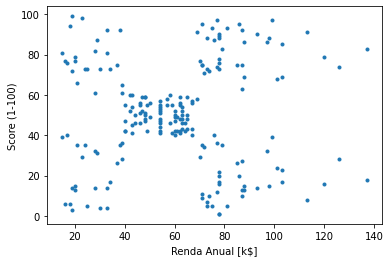

In [13]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], marker='.')
plt.xlabel('Renda Anual [k$]')
plt.ylabel('Score (1-100)')
plt.show()

Selecionando os dados para o agrupamento.

In [14]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)' ]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Importando a biblioteca K-means do Sklearn.

In [15]:
from sklearn.cluster import KMeans

Fazendo a clusterização com k = 5

In [16]:
model_kmeans = KMeans(n_clusters=5, init='k-means++')

In [17]:
y = model_kmeans.fit_predict(X)

In [18]:
print(y)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 1 4 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 3 0 3 1 3 0 3 0 3 1 3 0 3 0 3 0 3 0 3 1 3 0 3 0 3
 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3 0
 3 0 3 0 3 0 3 0 3 0 3 0 3 0 3]


Vizualizando o primeiro grupo criado.

In [19]:
print(X[y==0])

     Annual Income (k$)  Spending Score (1-100)
124                  70                      29
128                  71                      11
130                  71                       9
134                  73                       5
136                  73                       7
138                  74                      10
140                  75                       5
144                  77                      12
146                  77                      36
148                  78                      22
150                  78                      17
152                  78                      20
154                  78                      16
156                  78                       1
158                  78                       1
160                  79                      35
162                  81                       5
164                  85                      26
166                  86                      20
168                  87                 

Para visualizando os grupos faremos uma plotagem dentro de um loop.

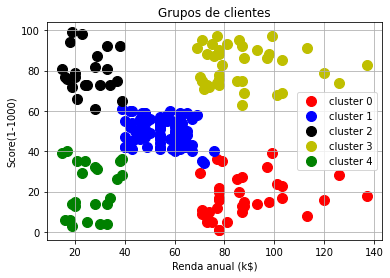

In [20]:
k_grupos = 5
cores = ['r', 'b', 'k', 'y', 'g']
for k in range(k_grupos):
  cluster = X[y==k]
  plt.scatter(cluster['Annual Income (k$)'], cluster['Spending Score (1-100)'], s=100, c=cores[k], label= f'cluster {k}')


plt.title('Grupos de clientes')
plt.xlabel('Renda anual (k$)')
plt.ylabel('Score(1-1000)')
plt.grid()
plt.legend()
plt.show()